In [1]:
# Entrenamiento y evaluacion de modelos de regresion supervisada — v6
# v6: añade elevacion (msnm de la capital provincial) como feature.
# Dataset principal: 276 registros (23 provincias x 12 meses), sin Galapagos.

import pandas as pd
import numpy as np
import os, json, joblib, unicodedata
from datetime import datetime
from sklearn.model_selection import train_test_split, cross_val_score, GroupKFold, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

# ── Elevacion de capital provincial (msnm) ────────────────────────────────────
# Fuente: Instituto Geográfico Militar del Ecuador / datos abiertos verificados.
# Incluye Galápagos (Puerto Baquerizo Moreno) solo para evaluacion OOD.
ELEVATION_DATA = {
    'Azuay':                           2560,   # Cuenca
    'Bolívar':                         2668,   # Guaranda
    'Cañar':                           2518,   # Azogues
    'Carchi':                          2957,   # Tulcán
    'Chimborazo':                      2754,   # Riobamba
    'Cotopaxi':                        2750,   # Latacunga
    'El Oro':                             4,   # Machala
    'Esmeraldas':                         5,   # Esmeraldas
    'Guayas':                             4,   # Guayaquil
    'Imbabura':                        2225,   # Ibarra
    'Loja':                            2060,   # Loja
    'Los Ríos':                           7,   # Babahoyo
    'Manabí':                            43,   # Portoviejo
    'Morona Santiago':                 1070,   # Macas
    'Napo':                             511,   # Tena
    'Orellana':                         254,   # Pto. Francisco de Orellana
    'Pastaza':                          950,   # Puyo
    'Pichincha':                       2850,   # Quito
    'Santa Elena':                       30,   # Santa Elena
    'Santo Domingo de los Tsáchilas':   550,   # Santo Domingo
    'Sucumbíos':                        295,   # Nueva Loja (Lago Agrio)
    'Tungurahua':                      2577,   # Ambato
    'Zamora Chinchipe':                 970,   # Zamora
    'Galápagos':                          6,   # Puerto Baquerizo Moreno (OOD)
}

def _norm_prov(s):
    """Sin tildes, minúsculas — para merge robusto."""
    return unicodedata.normalize('NFD', str(s)).encode('ascii','ignore').decode('ascii').lower()

ELEVATION_NORM = {_norm_prov(k): v for k, v in ELEVATION_DATA.items()}

# ── 1. Carga del dataset completo ─────────────────────────────────────────────
df_full = pd.read_csv('../data/processed/final_dataset_ecuador.csv')
print(f'[OK] Dataset completo: {len(df_full)} filas, {df_full["provincia"].nunique()} provincias')
assert len(df_full) == 288
assert df_full.isna().sum().sum() == 0

# ── 2. Merge de elevacion (antes de separar Galápagos) ───────────────────────
# Primero intenta match directo; si falla, usa nombre normalizado como fallback.
df_full['elevation'] = df_full['provincia'].map(
    lambda p: ELEVATION_DATA.get(p, ELEVATION_NORM.get(_norm_prov(p)))
)

n_nan = int(df_full['elevation'].isna().sum())
print(f'[OK] Elevacion unida. NaN: {n_nan}')
assert n_nan == 0, f'Hay {n_nan} NaN en elevation — revisar nombres de provincia'

print(f'     Rango: {int(df_full["elevation"].min())}m – {int(df_full["elevation"].max())}m')
print('\n     Provincia                                Elevacion (msnm)')
for prov, elev in df_full.groupby('provincia')['elevation'].first().sort_values().items():
    print(f'     {prov:<42} {int(elev):>5}')

# ── 3. Separar Galápagos (ya tiene elevation) ─────────────────────────────────
df_galapagos = df_full[df_full['provincia'] == 'Galápagos'].copy()
df = df_full[df_full['provincia'] != 'Galápagos'].reset_index(drop=True)
print(f'\n[OK] Galápagos excluida. Dataset principal: {len(df)} filas ({df["provincia"].nunique()} provincias).')
print(f'     Galápagos (OOD): {len(df_galapagos)} muestras, elevation={int(df_galapagos["elevation"].iloc[0])}m')

assert len(df) == 276 and df['provincia'].nunique() == 23

# ── 4. Feature sets v6 (añade elevation) ─────────────────────────────────────
features_solar_wind = ['latitude','longitude','month','temp_avg','wind_speed_avg','humidity_avg','elevation']
features_hydro      = ['latitude','longitude','month','temp_avg','wind_speed_avg','elevation']

X_sw = df[features_solar_wind].values
X_h  = df[features_hydro].values
y_solar = df['target_solar_kwh_per_m2'].values
y_wind  = df['target_wind_mwh'].values
y_hydro = df['target_hydro_mwh'].values
grupos  = df['provincia'].values
RS = 42

# ── 5. Split 80/20 ────────────────────────────────────────────────────────────
idx_tr, idx_te = train_test_split(np.arange(len(df)), test_size=0.2, random_state=RS)

imp_sw = SimpleImputer(strategy='median')
X_sw_tr = imp_sw.fit_transform(X_sw[idx_tr])
X_sw_te = imp_sw.transform(X_sw[idx_te])
imp_h   = SimpleImputer(strategy='median')
X_h_tr  = imp_h.fit_transform(X_h[idx_tr])
X_h_te  = imp_h.transform(X_h[idx_te])
g_tr = grupos[idx_tr]

print(f'\nEntrenamiento: {len(idx_tr)} muestras  |  Prueba: {len(idx_te)} muestras')
print('Features Solar/Eolico (v6):', features_solar_wind)
print('Features Hidrico       (v6):', features_hydro)

[OK] Dataset completo: 288 filas, 24 provincias
[OK] Elevacion unida. NaN: 0
     Rango: 4m – 2957m

     Provincia                                Elevacion (msnm)
     El Oro                                         4
     Guayas                                         4
     Esmeraldas                                     5
     Galápagos                                      6
     Los Ríos                                       7
     Santa Elena                                   30
     Manabí                                        43
     Orellana                                     254
     Sucumbíos                                    295
     Napo                                         511
     Santo Domingo de los Tsáchilas               550
     Pastaza                                      950
     Zamora Chinchipe                             970
     Morona Santiago                             1070
     Loja                                        2060
     Imbabura             

In [2]:
# Entrenamiento de modelos base + GridSearchCV para RF y GB

print('='*60)
print(' BUSQUEDA DE HIPERPARAMETROS (GridSearchCV + GroupKFold 3)')
print('='*60)

gkf3 = GroupKFold(n_splits=3)

param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
}
param_gb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_samples_split': [2, 5],
}

best_models = {}
best_params = {}

for name, Xtr, ytr in [
    ('solar', X_sw_tr, y_solar[idx_tr]),
    ('wind',  X_sw_tr, y_wind[idx_tr]),
    ('hydro', X_h_tr,  y_hydro[idx_tr]),
]:
    print(f'\n--- RF {name} ---')
    gs = GridSearchCV(RandomForestRegressor(random_state=RS, n_jobs=-1), param_rf,
                      cv=gkf3, scoring='r2', n_jobs=-1)
    gs.fit(Xtr, ytr, groups=g_tr)
    best_models[f'rf_{name}'] = gs.best_estimator_
    best_params[f'rf_{name}'] = gs.best_params_
    print(f'  Mejor R2: {gs.best_score_:.4f} | Params: {gs.best_params_}')

    print(f'--- GB {name} ---')
    gs2 = GridSearchCV(GradientBoostingRegressor(random_state=RS), param_gb,
                       cv=gkf3, scoring='r2', n_jobs=-1)
    gs2.fit(Xtr, ytr, groups=g_tr)
    best_models[f'gb_{name}'] = gs2.best_estimator_
    best_params[f'gb_{name}'] = gs2.best_params_
    print(f'  Mejor R2: {gs2.best_score_:.4f} | Params: {gs2.best_params_}')

# Regresion Lineal (baseline, sin GridSearch)
best_models['lr_solar'] = LinearRegression().fit(X_sw_tr, y_solar[idx_tr])
best_models['lr_wind']  = LinearRegression().fit(X_sw_tr, y_wind[idx_tr])
best_models['lr_hydro'] = LinearRegression().fit(X_h_tr,  y_hydro[idx_tr])
print('\n[OK] Todos los modelos entrenados.')


 BUSQUEDA DE HIPERPARAMETROS (GridSearchCV + GroupKFold 3)

--- RF solar ---


  Mejor R2: 0.0194 | Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
--- GB solar ---


  Mejor R2: 0.0040 | Params: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 100}

--- RF wind ---


  Mejor R2: 0.7488 | Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
--- GB wind ---


  Mejor R2: 0.7796 | Params: {'learning_rate': 0.2, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 200}

--- RF hydro ---


  Mejor R2: 0.4714 | Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
--- GB hydro ---


  Mejor R2: 0.5124 | Params: {'learning_rate': 0.2, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}

[OK] Todos los modelos entrenados.



===== TABLA IV — RESULTADOS FINALES =====
 Modelo         Algoritmo       MAE      RMSE     R²
  Solar       Reg. Lineal    1.8025    2.2531 0.3946
  Solar     Random Forest    1.0946    1.4130 0.7619
  Solar Gradient Boosting    1.0471    1.3224 0.7915
 Eolico       Reg. Lineal    4.7834    6.8657 0.8868
 Eolico     Random Forest    2.3738    4.0342 0.9609
 Eolico Gradient Boosting    1.9610    3.1312 0.9765
Hidrico       Reg. Lineal 4133.7154 5121.7538 0.3557
Hidrico     Random Forest 1762.8058 2172.5284 0.8841
Hidrico Gradient Boosting 1493.7730 1893.6700 0.9119

[OK] Sin data leakage. RF supera a LR en Solar. Resultados validos.


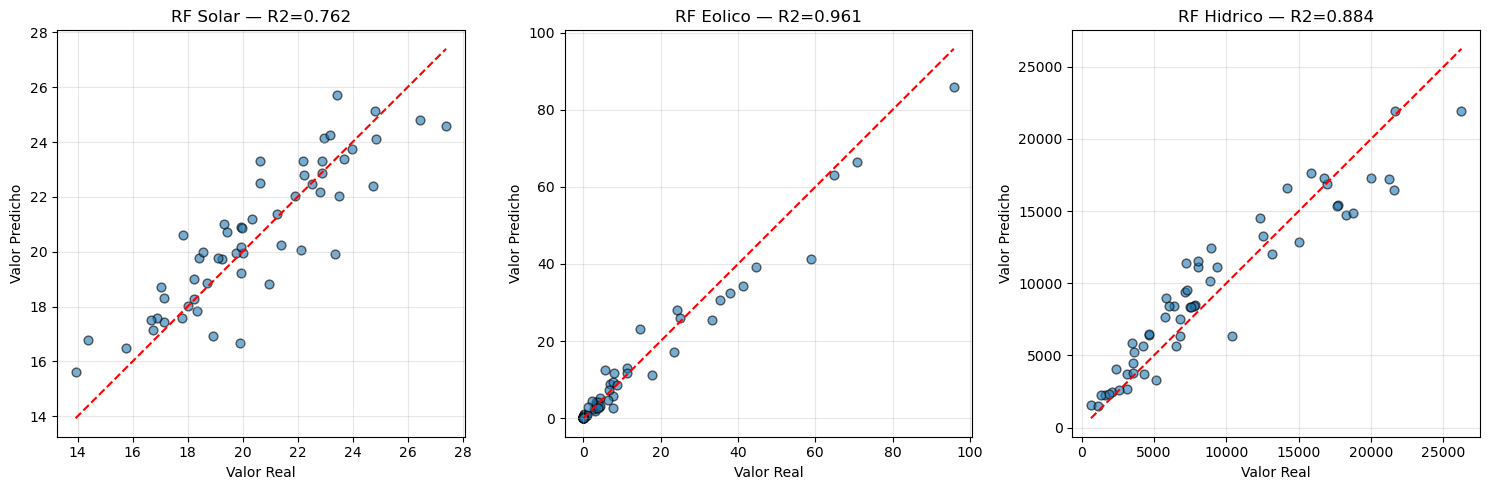

In [3]:
# Evaluacion de desempeno en conjunto de prueba (Tabla IV)

def metricas(y_true, y_pred):
    return (round(mean_absolute_error(y_true, y_pred), 4),
            round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
            round(r2_score(y_true, y_pred), 4))

resultados = []
for label, mk, Xte, yte in [
    ('Solar',   'solar', X_sw_te, y_solar[idx_te]),
    ('Eolico',  'wind',  X_sw_te, y_wind[idx_te]),
    ('Hidrico', 'hydro', X_h_te,  y_hydro[idx_te]),
]:
    for algo, prefix in [('Reg. Lineal','lr'), ('Random Forest','rf'), ('Gradient Boosting','gb')]:
        m = best_models[f'{prefix}_{mk}']
        mae, rmse, r2 = metricas(yte, m.predict(Xte))
        resultados.append({'Modelo': label, 'Algoritmo': algo,
                           'MAE': mae, 'RMSE': rmse, 'R²': r2})

df_results = pd.DataFrame(resultados)
print('\n===== TABLA IV — RESULTADOS FINALES =====')
print(df_results.to_string(index=False))

# Verificaciones criticas
r2_lr_h  = df_results[(df_results['Modelo']=='Hidrico') & (df_results['Algoritmo']=='Reg. Lineal')]['R²'].values[0]
r2_rf_s  = df_results[(df_results['Modelo']=='Solar')   & (df_results['Algoritmo']=='Random Forest')]['R²'].values[0]
r2_lr_s  = df_results[(df_results['Modelo']=='Solar')   & (df_results['Algoritmo']=='Reg. Lineal')]['R²'].values[0]
assert r2_lr_h < 0.99, f'LEAKAGE HIDRICO: R2={r2_lr_h}'
assert r2_rf_s > r2_lr_s, f'RF Solar ({r2_rf_s}) deberia superar LR ({r2_lr_s})'
print('\n[OK] Sin data leakage. RF supera a LR en Solar. Resultados validos.')

# Grafico reales vs predichos para cada energia
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (label, mk, Xte, yte) in zip(axes, [
    ('Solar',   'solar', X_sw_te, y_solar[idx_te]),
    ('Eolico',  'wind',  X_sw_te, y_wind[idx_te]),
    ('Hidrico', 'hydro', X_h_te,  y_hydro[idx_te]),
]):
    yp = best_models[f'rf_{mk}'].predict(Xte)
    ax.scatter(yte, yp, alpha=0.6, edgecolors='k', s=40)
    lims = [min(yte.min(), yp.min()), max(yte.max(), yp.max())]
    ax.plot(lims, lims, 'r--', lw=1.5)
    r2 = round(r2_score(yte, yp), 3)
    ax.set_title(f'RF {label} — R2={r2}')
    ax.set_xlabel('Valor Real'); ax.set_ylabel('Valor Predicho')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [4]:
# Validacion cruzada GroupKFold(5) — generalizacion provincial (v6)

print('='*60)
print(' VALIDACION CRUZADA GroupKFold(5)  [v6, con elevation]')
print('='*60)
print('Nota: cada pliegue excluye ~4-5 provincias (23 total).\n')

gkf5 = GroupKFold(n_splits=5)
imp_sw_f = SimpleImputer(strategy='median').fit_transform(X_sw)
imp_h_f  = SimpleImputer(strategy='median').fit_transform(X_h)

cv_results = []
for label, mk, Xf, yf in [
    ('Solar',   'solar', imp_sw_f, y_solar),
    ('Eolico',  'wind',  imp_sw_f, y_wind),
    ('Hidrico', 'hydro', imp_h_f,  y_hydro),
]:
    for algo, prefix in [('Reg. Lineal','lr'),('Random Forest','rf'),('Gradient Boosting','gb')]:
        m  = best_models[f'{prefix}_{mk}']
        sc = cross_val_score(m, Xf, yf, cv=gkf5, groups=grupos, scoring='r2')
        cv_results.append({'Modelo': label, 'Algoritmo': algo,
                           'R² medio': round(sc.mean(), 4),
                           'Desv. Est.': round(sc.std(), 4)})
        print(f'  {label:8} {algo:20} R2={sc.mean():.4f} +/-{sc.std():.4f}')

df_cv = pd.DataFrame(cv_results)

# Guardar tabla GroupKFold v6
os.makedirs('../data/processed', exist_ok=True)
df_cv.to_csv('../data/processed/tabla_groupkfold_v6.csv', index=False)
print('\n[OK] tabla_groupkfold_v6.csv guardada')

# ── Comparacion v5 vs v6 ─────────────────────────────────────────────────────
print('\n' + '='*72)
print(' COMPARACION GroupKFold R² medio — v5 (sin elevation) vs v6 (con elevation)')
print('='*72)
try:
    with open('../models/metadata_v5.json', encoding='utf-8') as f:
        meta_v5 = json.load(f)
    df_v5 = pd.DataFrame(meta_v5['cv_results_gkf5'])
    df_cmp = (
        df_v5[['Modelo','Algoritmo','R² medio']]
        .rename(columns={'R² medio': 'R²_v5'})
        .merge(
            df_cv[['Modelo','Algoritmo','R² medio']].rename(columns={'R² medio': 'R²_v6'}),
            on=['Modelo','Algoritmo']
        )
    )
    df_cmp['Δ(v6−v5)'] = (df_cmp['R²_v6'] - df_cmp['R²_v5']).round(4)
    df_cmp['mejora'] = df_cmp['Δ(v6−v5)'].apply(lambda x: '▲' if x > 0 else ('▼' if x < 0 else '='))
    print(df_cmp.to_string(index=False))
    n_mejor = (df_cmp['Δ(v6−v5)'] > 0).sum()
    print(f'\n  Modelos que mejoran al añadir elevation: {n_mejor}/9')
    print(f'  Δ medio: {df_cmp["Δ(v6−v5)"].mean():.4f}')
except FileNotFoundError:
    print('  [AVISO] metadata_v5.json no encontrado — omitiendo comparacion v5 vs v6')

 VALIDACION CRUZADA GroupKFold(5)  [v6, con elevation]
Nota: cada pliegue excluye ~4-5 provincias (23 total).

  Solar    Reg. Lineal          R2=-0.0439 +/-0.4859


  Solar    Random Forest        R2=0.0227 +/-0.4494
  Solar    Gradient Boosting    R2=-0.0386 +/-0.6086
  Eolico   Reg. Lineal          R2=0.3409 +/-0.7822


  Eolico   Random Forest        R2=0.5922 +/-0.3848


  Eolico   Gradient Boosting    R2=0.6292 +/-0.2871
  Hidrico  Reg. Lineal          R2=0.3303 +/-0.3008


  Hidrico  Random Forest        R2=0.4202 +/-0.1575
  Hidrico  Gradient Boosting    R2=0.4665 +/-0.1901

[OK] tabla_groupkfold_v6.csv guardada

 COMPARACION GroupKFold R² medio — v5 (sin elevation) vs v6 (con elevation)
 Modelo         Algoritmo   R²_v5   R²_v6  Δ(v6−v5) mejora
  Solar       Reg. Lineal -0.1737 -0.0439    0.1298      ▲
  Solar     Random Forest  0.1337  0.0227   -0.1110      ▼
  Solar Gradient Boosting -0.0992 -0.0386    0.0606      ▲
 Eolico       Reg. Lineal  0.4463  0.3409   -0.1054      ▼
 Eolico     Random Forest  0.5538  0.5922    0.0384      ▲
 Eolico Gradient Boosting  0.6098  0.6292    0.0194      ▲
Hidrico       Reg. Lineal  0.3652  0.3303   -0.0349      ▼
Hidrico     Random Forest  0.4370  0.4202   -0.0168      ▼
Hidrico Gradient Boosting  0.5087  0.4665   -0.0422      ▼

  Modelos que mejoran al añadir elevation: 4/9
  Δ medio: -0.0069


In [5]:
# === TAREA 2: Baselines triviales — GroupKFold(5) ===
# Baseline_mean:    DummyRegressor(strategy='mean') — predice la media global de train.
# Baseline_mensual: predice la media del target para el mes del sample (calculada en train).
# Comparacion con LR, RF, GB usando los mismos folds.

from sklearn.dummy import DummyRegressor
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import cross_validate

class MonthMeanPredictor(BaseEstimator, RegressorMixin):
    """
    Predice la media del target para el mes de cada muestra.
    Mes tomado de la columna 2 del array de features
    (posicion fija en ambos feature sets: [lat, lon, month, ...]).
    """
    def __init__(self, month_col_idx=2):
        self.month_col_idx = month_col_idx

    def fit(self, X, y):
        self.global_mean_ = float(y.mean())
        months = X[:, self.month_col_idx].astype(int)
        self.month_means_ = {int(m): float(y[months == m].mean())
                             for m in np.unique(months)}
        return self

    def predict(self, X):
        months = X[:, self.month_col_idx].astype(int)
        return np.array([self.month_means_.get(int(m), self.global_mean_)
                         for m in months])

scoring = {
    'r2':   'r2',
    'mae':  'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
}
gkf5_bl = GroupKFold(n_splits=5)

print('='*65)
print(' BASELINES + COMPARACION COMPLETA — GroupKFold(5)')
print('='*65)

all_bl_rows = []
for label, mk, Xf, yf in [
    ('Solar',   'solar', imp_sw_f, y_solar),
    ('Eolico',  'wind',  imp_sw_f, y_wind),
    ('Hidrico', 'hydro', imp_h_f,  y_hydro),
]:
    contenders = [
        ('Baseline_mean',    DummyRegressor(strategy='mean')),
        ('Baseline_mensual', MonthMeanPredictor(month_col_idx=2)),
        ('LR',               best_models[f'lr_{mk}']),
        ('RF',               best_models[f'rf_{mk}']),
        ('GB',               best_models[f'gb_{mk}']),
    ]
    for algo_name, model in contenders:
        cv = cross_validate(model, Xf, yf, cv=gkf5_bl, groups=grupos,
                            scoring=scoring, error_score='raise')
        all_bl_rows.append({
            'Modelo':    label,
            'Algoritmo': algo_name,
            'R²':        round(float(cv['test_r2'].mean()),    4),
            'MAE':       round(float(-cv['test_mae'].mean()),  4),
            'RMSE':      round(float(-cv['test_rmse'].mean()), 4),
        })

df_baselines = pd.DataFrame(all_bl_rows)

# ── Tabla comparativa por target ─────────────────────────────────────────────
for label in ['Solar', 'Eolico', 'Hidrico']:
    sub = df_baselines[df_baselines['Modelo'] == label][['Algoritmo','R²','MAE','RMSE']]
    print(f'\n--- {label} ---')
    print(sub.to_string(index=False))

# Guardar tabla completa (incluye modelos + baselines)
os.makedirs('../data/processed', exist_ok=True)
df_baselines.to_csv('../data/processed/tabla_baselines.csv', index=False)
print('\n[OK] tabla_baselines.csv guardada en data/processed/')

 BASELINES + COMPARACION COMPLETA — GroupKFold(5)



--- Solar ---
       Algoritmo      R²    MAE   RMSE
   Baseline_mean -0.2344 2.7354 3.2750
Baseline_mensual  0.0058 2.3732 2.9209
              LR -0.0439 2.3338 2.9587
              RF  0.0227 2.2879 2.8351
              GB -0.0386 2.2798 2.8735

--- Eolico ---
       Algoritmo      R²     MAE    RMSE
   Baseline_mean -1.0879 14.9824 21.1977
Baseline_mensual -1.1776 14.4977 20.7264
              LR  0.3409  7.1415  9.5060
              RF  0.5922  5.4346 10.1831
              GB  0.6292  5.1782  9.5899

--- Hidrico ---
       Algoritmo      R²       MAE      RMSE
   Baseline_mean -0.0317 5305.9155 6309.0658
Baseline_mensual  0.3728 4027.1828 4923.6073
              LR  0.3303 4081.1199 4928.9315
              RF  0.4202 3649.3833 4680.0768
              GB  0.4665 3422.7592 4441.8775

[OK] tabla_baselines.csv guardada en data/processed/


In [6]:
# Exportacion de modelos v6 (con elevation, 23 provincias, sin Galápagos)
# Los modelos v4 y v5 se conservan intactos en models/.

os.makedirs('../models', exist_ok=True)

# ── Guardar modelos v6 ────────────────────────────────────────────────────────
joblib.dump(best_models['rf_solar'], '../models/model_solar_v6.joblib')
joblib.dump(best_models['rf_wind'],  '../models/model_wind_v6.joblib')
joblib.dump(best_models['rf_hydro'], '../models/model_hydro_v6.joblib')
print('[OK] Modelos RF v6 exportados (con elevation, sin Galápagos)')

# ── Verificar que v4 y v5 siguen intactos ─────────────────────────────────────
for ver in ('v4', 'v5'):
    for tgt in ('solar', 'wind', 'hydro'):
        path = f'../models/model_{tgt}_{ver}.joblib'
        status = '[OK]' if os.path.exists(path) else '[AVISO NO encontrado]'
        print(f'  {status} {path}')

# ── Tabla IV v6 (hold-out 80/20) ─────────────────────────────────────────────
os.makedirs('../data/processed', exist_ok=True)
df_results.to_csv('../data/processed/tabla_iv_resultados_v6.csv', index=False)
print('[OK] tabla_iv_resultados_v6.csv guardada en data/processed/')

# ── Metadatos v6 ─────────────────────────────────────────────────────────────
metadata_v6 = {
    'version': 'v6',
    'fecha_entrenamiento': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'descripcion': (
        'Dataset sin Galápagos (276 filas, 23 provincias x 12 meses). '
        'v6: elevation (msnm de capital provincial) añadido como feature. '
        'Solar/Eolico: 7 features. Hidrico: 6 features (sin humidity_avg). '
        'PVGIS fuente primaria, precipitacion NASA POWER mensual, '
        'runoff_coeff fijo 0.35, Hellman 10m->100m, GridSearchCV+GroupKFold.'
    ),
    'provincias_entrenamiento': sorted(df['provincia'].unique().tolist()),
    'provincia_excluida': 'Galápagos (evaluada como out-of-domain)',
    'features_solar_wind': features_solar_wind,
    'features_hydro': features_hydro,
    'n_registros': len(df),
    'test_size': 0.2,
    'random_state': RS,
    'hiperparametros': best_params,
    'metricas_validacion': df_results.to_dict(orient='records'),
    'cv_results_gkf5': df_cv.to_dict(orient='records'),
}
with open('../models/metadata_v6.json', 'w', encoding='utf-8') as f:
    json.dump(metadata_v6, f, indent=2, ensure_ascii=False)
print('[OK] metadata_v6.json guardado en models/')

print('\n Proceso de Modelado v6 completado.')
print(f' Features Solar/Eolico : {features_solar_wind}')
print(f' Features Hidrico      : {features_hydro}')
print(f' Provincias            : {df["provincia"].nunique()} (sin Galápagos)')


[OK] Modelos RF v6 exportados (con elevation, sin Galápagos)
  [OK] ../models/model_solar_v4.joblib
  [OK] ../models/model_wind_v4.joblib
  [OK] ../models/model_hydro_v4.joblib
  [OK] ../models/model_solar_v5.joblib
  [OK] ../models/model_wind_v5.joblib
  [OK] ../models/model_hydro_v5.joblib
[OK] tabla_iv_resultados_v6.csv guardada en data/processed/
[OK] metadata_v6.json guardado en models/

 Proceso de Modelado v6 completado.
 Features Solar/Eolico : ['latitude', 'longitude', 'month', 'temp_avg', 'wind_speed_avg', 'humidity_avg', 'elevation']
 Features Hidrico      : ['latitude', 'longitude', 'month', 'temp_avg', 'wind_speed_avg', 'elevation']
 Provincias            : 23 (sin Galápagos)


In [7]:
# === MEJORA 1: Intervalos de confianza bootstrap (n=1000) ===
# Remuestreo con reemplazo sobre el conjunto de prueba (58 muestras).
# Reporta media, IC95% (p2.5, p97.5) y desv. est. para R², MAE y RMSE.
# Reproducible con numpy.random.default_rng(42).

rng   = np.random.default_rng(42)
N_BOOT = 1000
n_te   = len(idx_te)

print('=' * 65)
print(' INTERVALOS DE CONFIANZA BOOTSTRAP  (n_iter=1000, seed=42)')
print('=' * 65)

test_cases_b = [
    ('Solar',   'solar', X_sw_te, y_solar[idx_te]),
    ('Eolico',  'wind',  X_sw_te, y_wind[idx_te]),
    ('Hidrico', 'hydro', X_h_te,  y_hydro[idx_te]),
]

boot_rows = []
for label, mk, Xte, yte in test_cases_b:
    for algo, prefix in [('Reg. Lineal','lr'), ('Random Forest','rf'), ('Gradient Boosting','gb')]:
        model = best_models[f'{prefix}_{mk}']
        yp    = model.predict(Xte)

        r2_b, mae_b, rmse_b = [], [], []
        for _ in range(N_BOOT):
            idx_b  = rng.integers(0, n_te, size=n_te)
            r2_b.append(r2_score(yte[idx_b], yp[idx_b]))
            mae_b.append(mean_absolute_error(yte[idx_b], yp[idx_b]))
            rmse_b.append(float(np.sqrt(mean_squared_error(yte[idx_b], yp[idx_b]))))

        boot_rows.append({
            'Modelo':    label,
            'Algoritmo': algo,
            'R2_media':  round(float(np.mean(r2_b)),           4),
            'R2_p2.5':   round(float(np.percentile(r2_b, 2.5)), 4),
            'R2_p97.5':  round(float(np.percentile(r2_b,97.5)), 4),
            'R2_std':    round(float(np.std(r2_b)),             4),
            'MAE_media': round(float(np.mean(mae_b)),           4),
            'MAE_p2.5':  round(float(np.percentile(mae_b, 2.5)),4),
            'MAE_p97.5': round(float(np.percentile(mae_b,97.5)),4),
            'RMSE_media':round(float(np.mean(rmse_b)),          4),
            'RMSE_p2.5': round(float(np.percentile(rmse_b,2.5)),4),
            'RMSE_p97.5':round(float(np.percentile(rmse_b,97.5)),4),
        })

df_boot = pd.DataFrame(boot_rows)
df_boot['R2 (IC95%)']   = df_boot.apply(
    lambda r: f"{r['R2_media']:.4f} [{r['R2_p2.5']:.4f}, {r['R2_p97.5']:.4f}]", axis=1)
df_boot['MAE (IC95%)']  = df_boot.apply(
    lambda r: f"{r['MAE_media']:.4f} [{r['MAE_p2.5']:.4f}, {r['MAE_p97.5']:.4f}]", axis=1)
df_boot['RMSE (IC95%)'] = df_boot.apply(
    lambda r: f"{r['RMSE_media']:.4f} [{r['RMSE_p2.5']:.4f}, {r['RMSE_p97.5']:.4f}]", axis=1)

print('\nR² con IC95%:')
print(df_boot[['Modelo','Algoritmo','R2 (IC95%)']].to_string(index=False))
print('\nMAE con IC95%:')
print(df_boot[['Modelo','Algoritmo','MAE (IC95%)']].to_string(index=False))
print('\nRMSE con IC95%:')
print(df_boot[['Modelo','Algoritmo','RMSE (IC95%)']].to_string(index=False))

os.makedirs('../data/processed', exist_ok=True)

# Guardar v6 (nueva) y mantener la copia generica
df_boot.to_csv('../data/processed/tabla_bootstrap_ci_v6.csv', index=False)
print('\n[OK] tabla_bootstrap_ci_v6.csv guardada en data/processed/')

df_boot.to_csv('../data/processed/tabla_bootstrap_ci.csv', index=False)
print('[OK] tabla_bootstrap_ci.csv actualizada en data/processed/')


 INTERVALOS DE CONFIANZA BOOTSTRAP  (n_iter=1000, seed=42)



R² con IC95%:
 Modelo         Algoritmo              R2 (IC95%)
  Solar       Reg. Lineal 0.3726 [0.0762, 0.5891]
  Solar     Random Forest 0.7519 [0.6151, 0.8398]
  Solar Gradient Boosting 0.7852 [0.6806, 0.8570]
 Eolico       Reg. Lineal 0.8782 [0.7833, 0.9321]
 Eolico     Random Forest 0.9570 [0.9108, 0.9814]
 Eolico Gradient Boosting 0.9740 [0.9507, 0.9885]
Hidrico       Reg. Lineal 0.3391 [0.0868, 0.5179]
Hidrico     Random Forest 0.8800 [0.8291, 0.9185]
Hidrico Gradient Boosting 0.9083 [0.8572, 0.9418]

MAE con IC95%:
 Modelo         Algoritmo                      MAE (IC95%)
  Solar       Reg. Lineal          1.8047 [1.4705, 2.1667]
  Solar     Random Forest          1.0894 [0.8706, 1.3128]
  Solar Gradient Boosting          1.0449 [0.8156, 1.2425]
 Eolico       Reg. Lineal          4.7641 [3.5807, 6.1743]
 Eolico     Random Forest          2.3729 [1.5735, 3.2210]
 Eolico Gradient Boosting          1.9753 [1.3571, 2.6433]
Hidrico       Reg. Lineal 4125.7505 [3351.2947, 4902.803

In [8]:
# === MEJORA 2 / TAREA 4: Analisis SHAP — RF v6 (con elevation) ===
# TreeExplainer sobre RF solar, RF wind, RF hydro ya entrenados sin Galápagos.
# Solar v6: guarda adicionalmente shap_solar_v6.png / shap_solar_beeswarm_v6.png
#           y verifica si elevation aparece en el top-3 de importancia.
# Eolico: los valores SHAP se recortan a [-50, 50] SOLO para visualizacion.
# El recorte elimina el efecto del outlier wind_speed_avg en la escala del grafico.
# Los valores originales se conservan en shap_values_orig para cualquier calculo.

import subprocess, sys
try:
    import shap
    print(f'shap disponible: {shap.__version__}')
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'shap', '-q'], check=True)
    import shap
    print(f'shap instalado')

os.makedirs('../docs', exist_ok=True)

shap_cases = [
    ('Solar',   'solar', X_sw_te, features_solar_wind),
    ('Eolico',  'wind',  X_sw_te, features_solar_wind),
    ('Hidrico', 'hydro', X_h_te,  features_hydro),
]
slug_shap = {'Solar': 'solar', 'Eolico': 'eolico', 'Hidrico': 'hidrico'}

for label, mk, Xte, feat_names in shap_cases:
    model = best_models[f'rf_{mk}']
    Xte_df = pd.DataFrame(Xte, columns=feat_names)
    slug = slug_shap[label]

    explainer        = shap.TreeExplainer(model)
    shap_values_orig = explainer.shap_values(Xte_df)   # valores originales

    # Para eolico: recortar a [-50, 50] SOLO para visualizacion
    if mk == 'wind':
        shap_plot = np.clip(shap_values_orig, -50, 50)
        max_orig = np.abs(shap_values_orig).max()
        print(f'  [INFO] SHAP eolico recortado [-50,50] para viz. Max original: {max_orig:.1f}')
    else:
        shap_plot = shap_values_orig

    # ── Bar plot: importancia media absoluta ─────────────────────────────
    shap.summary_plot(shap_plot, Xte_df, plot_type='bar', show=False)
    plt.title(f'SHAP Importancia de Variables — {label} (RF v6)', fontsize=12)
    plt.tight_layout()
    bar_path = f'../docs/shap_{slug}.png'
    plt.savefig(bar_path, dpi=150, bbox_inches='tight')
    if mk == 'solar':
        plt.savefig('../docs/shap_solar_v6.png', dpi=150, bbox_inches='tight')
    plt.close()

    # ── Beeswarm: direccion e intensidad ─────────────────────────────────
    shap.summary_plot(shap_plot, Xte_df, show=False)
    plt.title(f'SHAP Beeswarm — {label} (RF v6)', fontsize=12)
    plt.tight_layout()
    bswarm_path = f'../docs/shap_{slug}_beeswarm.png'
    plt.savefig(bswarm_path, dpi=150, bbox_inches='tight')
    if mk == 'solar':
        plt.savefig('../docs/shap_solar_beeswarm_v6.png', dpi=150, bbox_inches='tight')
    plt.close()

    print(f'[OK] SHAP {label}: {bar_path}  +  {bswarm_path}')

    # ── Verificar si elevation esta en el top-3 (solo para solar) ────────
    if mk == 'solar':
        mean_abs_shap = np.abs(shap_values_orig).mean(axis=0)
        ranked = sorted(zip(feat_names, mean_abs_shap), key=lambda x: x[1], reverse=True)
        top3 = [r[0] for r in ranked[:3]]
        elevation_rank = next((i+1 for i, (f, _) in enumerate(ranked) if f == 'elevation'), None)
        print(f'\n  SHAP Solar v6 — Ranking de features por |SHAP| medio:')
        for i, (f, v) in enumerate(ranked):
            tag = ' ← elevation' if f == 'elevation' else ''
            print(f'    {i+1}. {f:<32}  {v:.4f}{tag}')
        if elevation_rank is not None and elevation_rank <= 3:
            print(f'\n  [OK] elevation en TOP-3 (posicion {elevation_rank}) para Solar v6')
        else:
            print(f'\n  [INFO] elevation en posicion {elevation_rank}/7 para Solar v6')
        print(f'  v6 barplots: docs/shap_solar_v6.png  +  docs/shap_solar_beeswarm_v6.png')

print('\n[OK] Analisis SHAP v6 completado (6 graficos + 2 extra solar_v6 en docs/).')


shap disponible: 0.48.0


[OK] SHAP Solar: ../docs/shap_solar.png  +  ../docs/shap_solar_beeswarm.png

  SHAP Solar v6 — Ranking de features por |SHAP| medio:
    1. temp_avg                          1.4163
    2. month                             0.8859
    3. humidity_avg                      0.6116
    4. longitude                         0.3139
    5. elevation                         0.2285 ← elevation
    6. latitude                          0.1510
    7. wind_speed_avg                    0.1042

  [INFO] elevation en posicion 5/7 para Solar v6
  v6 barplots: docs/shap_solar_v6.png  +  docs/shap_solar_beeswarm_v6.png
  [INFO] SHAP eolico recortado [-50,50] para viz. Max original: 57.2


[OK] SHAP Eolico: ../docs/shap_eolico.png  +  ../docs/shap_eolico_beeswarm.png


[OK] SHAP Hidrico: ../docs/shap_hidrico.png  +  ../docs/shap_hidrico_beeswarm.png

[OK] Analisis SHAP v6 completado (6 graficos + 2 extra solar_v6 en docs/).


[OK] GeoJSON: 24 provincias
[OK] Mediana nacional eolico (23 prov.): 3.4108 MWh


[OK] Predicciones OOF: 276 muestras, 23 provincias cubiertas.

 Solar — 5 provincias MAYOR error relativo
  provincia      mae  error_rel
Santa Elena 6.224925   0.260956
  Pichincha 4.308772   0.219992
     Manabí 3.258513   0.187856
     El Oro 3.621427   0.161228
   Los Ríos 2.321914   0.145576

 Solar — 5 provincias MENOR error relativo
provincia      mae  error_rel
 Cotopaxi 0.928398   0.039486
  Bolívar 1.020076   0.047298
  Pastaza 1.078647   0.052627
     Napo 1.166891   0.057512
    Cañar 1.446458   0.069346


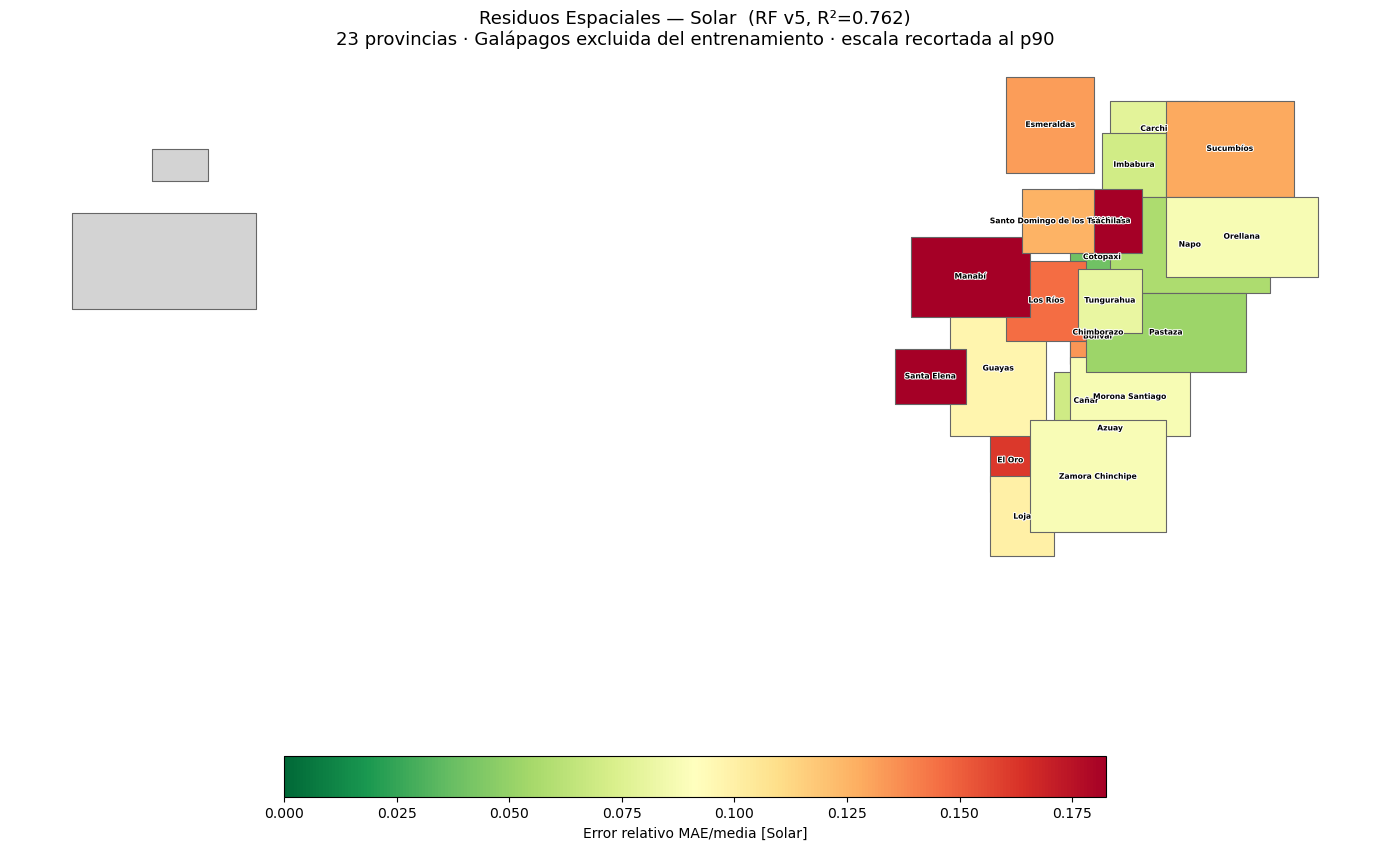

[OK] ../docs/residuos_solar.png guardado

 Eolico — Top 5 mayor MAE ABSOLUTO (MWh)
  provincia       mae
Santa Elena 22.192279
 Esmeraldas 20.135119
      Azuay 17.707095
   Cotopaxi 10.547457
     Guayas  8.918301

 Eolico — Top 5 mayor ERROR % respecto mediana nacional
  provincia       mae  error_pct_mediana
Santa Elena 22.192279         650.637781
 Esmeraldas 20.135119         590.325538
      Azuay 17.707095         519.140245
   Cotopaxi 10.547457         309.232507
     Guayas  8.918301         261.468584

 Eolico — 5 provincias con MENOR error %
      provincia      mae  error_pct_mediana
           Napo 0.102191           2.996058
      Sucumbíos 0.156540           4.589484
       Orellana 0.174987           5.130319
Morona Santiago 0.248917           7.297803
       Los Ríos 0.580620          17.022731


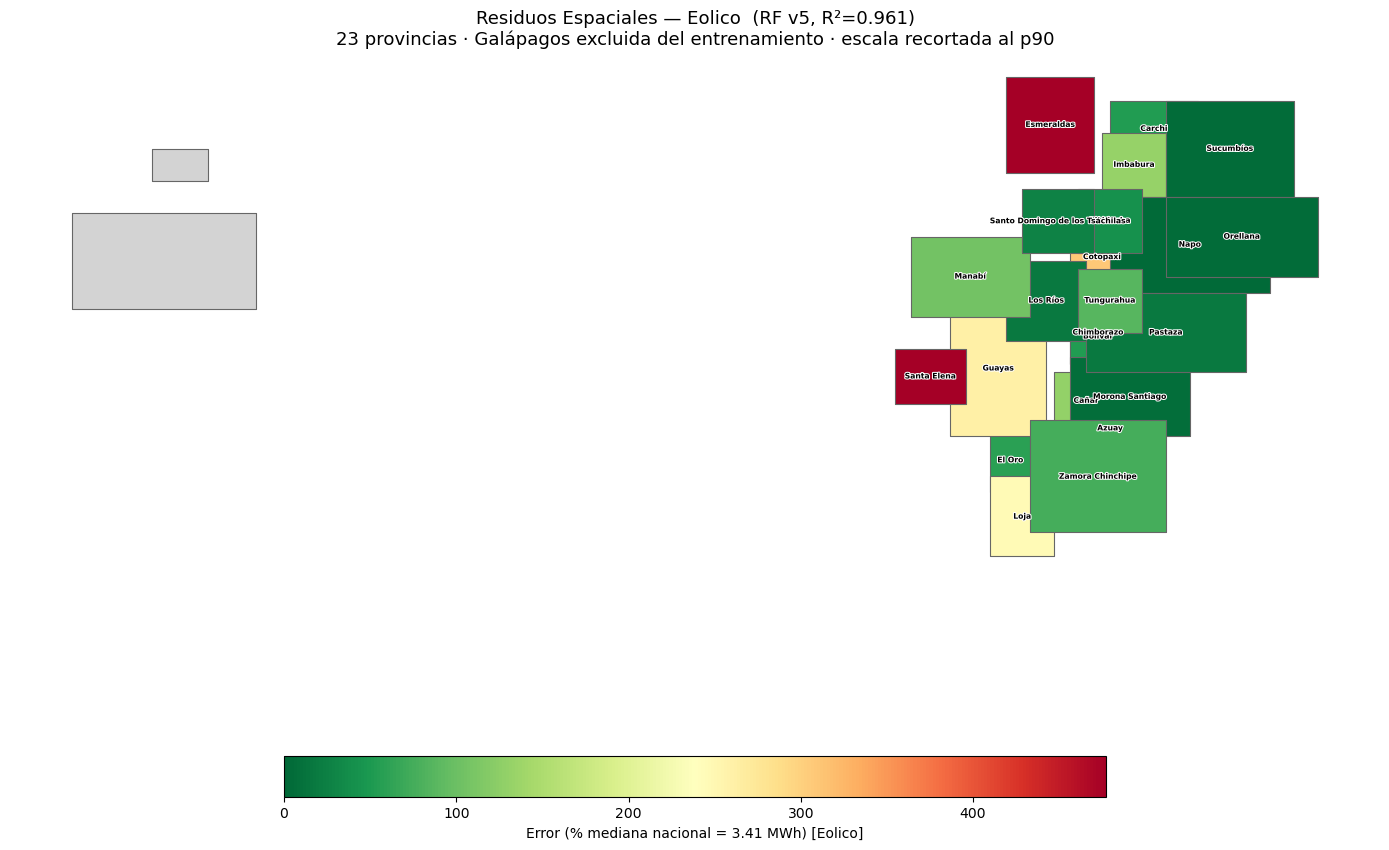

[OK] ../docs/residuos_eolico.png guardado

 Hidrico — 5 provincias MAYOR error relativo
  provincia         mae  error_rel
Santa Elena 5324.869492   1.254977
     El Oro 4294.513750   1.159522
     Carchi 8078.619896   1.027873
       Napo 6373.495355   0.573836
      Azuay 2819.734175   0.554612

 Hidrico — 5 provincias MENOR error relativo
       provincia         mae  error_rel
        Cotopaxi 1524.565658   0.152881
 Morona Santiago 2366.574282   0.157643
        Los Ríos 1364.317105   0.158188
Zamora Chinchipe  882.903856   0.158637
            Loja  873.342582   0.194071


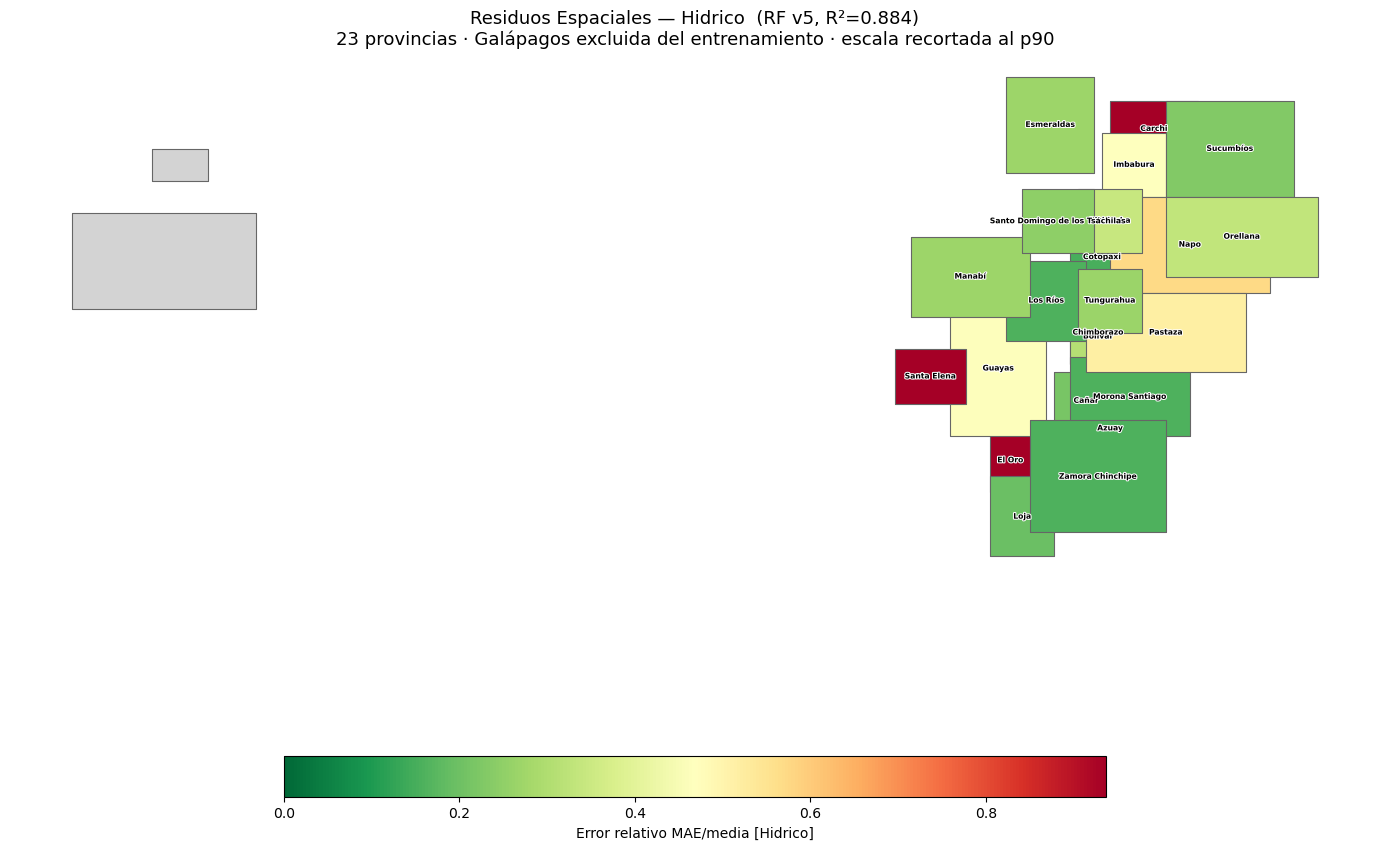

[OK] ../docs/residuos_hidrico.png guardado

[OK] Analisis de residuos espaciales completado.


In [9]:
# === MEJORA 3: Analisis de residuos espaciales por provincia (v5) ===
# OOF GroupKFold(5) sobre 23 provincias (sin Galápagos).
# Eolico: metricas DUALES — MAE absoluto (MWh) + % respecto a mediana nacional.
#   NO se usa error relativo local (infla en provincias amazonicas con target~0).
# Solar / Hidrico: error relativo = MAE / media provincial (sin cambios).
# Mapas: figsize (14,12), etiquetas de provincia, escala recortada al p90.

import geopandas as gpd
import unicodedata
from sklearn.model_selection import cross_val_predict
from sklearn.base import clone
import matplotlib.patheffects as pe

def _norm(s):
    return unicodedata.normalize('NFD', str(s)).encode('ascii','ignore').decode('ascii').lower()

# ── Cargar GeoJSON ────────────────────────────────────────────────────────────
gdf_prov = gpd.read_file('../data/raw/ecuador_provincias_poligonos.geojson')
gdf_prov['nombre_norm'] = gdf_prov['nombre'].apply(_norm)
print(f'[OK] GeoJSON: {len(gdf_prov)} provincias')

# ── Mediana nacional eolico (sin Galápagos) ───────────────────────────────────
mediana_nacional_eolico = float(np.median(y_wind))
print(f'[OK] Mediana nacional eolico (23 prov.): {mediana_nacional_eolico:.4f} MWh')

# ── Predicciones OOF (276 muestras, 23 provincias) ───────────────────────────
gkf5_r  = GroupKFold(n_splits=5)
oof_cases = [
    ('Solar',   'solar', imp_sw_f, y_solar),
    ('Eolico',  'wind',  imp_sw_f, y_wind),
    ('Hidrico', 'hydro', imp_h_f,  y_hydro),
]

df_oof = df[['provincia']].copy()
for label, mk, Xf, yf in oof_cases:
    m_clone = clone(best_models[f'rf_{mk}'])
    y_oof = cross_val_predict(m_clone, Xf, yf, cv=gkf5_r, groups=grupos)
    df_oof[f'residuo_{mk}'] = np.abs(yf - y_oof)
    df_oof[f'target_{mk}']  = yf
print('[OK] Predicciones OOF: 276 muestras, 23 provincias cubiertas.')

slug_map = {'Solar': 'solar', 'Eolico': 'eolico', 'Hidrico': 'hidrico'}

for label, mk, Xf, yf in oof_cases:
    # ── Calcular error por provincia ──────────────────────────────────────
    prov_err = df_oof.groupby('provincia').agg(
        mae      = (f'residuo_{mk}', 'mean'),
        media_tgt= (f'target_{mk}',  'mean')
    ).reset_index()

    if mk == 'wind':
        # ── Metricas DUALES para eolico ───────────────────────────────────
        prov_err['error_pct_mediana'] = (
            prov_err['mae'] / mediana_nacional_eolico * 100
        )
        plot_col   = 'error_pct_mediana'
        plot_label = f'Error (% mediana nacional = {mediana_nacional_eolico:.2f} MWh) [{label}]'

        print(f'\n{"="*60}')
        print(f' Eolico — Top 5 mayor MAE ABSOLUTO (MWh)')
        print(f'{"="*60}')
        print(prov_err.nlargest(5, 'mae')[['provincia','mae']].to_string(index=False))

        print(f'\n Eolico — Top 5 mayor ERROR % respecto mediana nacional')
        print(f'{"="*60}')
        top5_pct = prov_err.nlargest(5, 'error_pct_mediana')[
            ['provincia','mae','error_pct_mediana']]
        print(top5_pct.to_string(index=False))

        print(f'\n Eolico — 5 provincias con MENOR error %')
        low5_pct = prov_err.nsmallest(5, 'error_pct_mediana')[
            ['provincia','mae','error_pct_mediana']]
        print(low5_pct.to_string(index=False))
    else:
        # ── Error relativo para solar e hidrico ───────────────────────────
        prov_err['error_rel'] = prov_err['mae'] / prov_err['media_tgt']
        plot_col   = 'error_rel'
        plot_label = f'Error relativo MAE/media [{label}]'

        print(f'\n{"="*60}')
        print(f' {label} — 5 provincias MAYOR error relativo')
        print(f'{"="*60}')
        print(prov_err.nlargest(5,'error_rel')[['provincia','mae','error_rel']].to_string(index=False))
        print(f'\n {label} — 5 provincias MENOR error relativo')
        print(prov_err.nsmallest(5,'error_rel')[['provincia','mae','error_rel']].to_string(index=False))

    # ── R² del modelo en test (para el titulo del mapa) ──────────────────
    r2_mod = df_results.loc[
        (df_results['Modelo']==label) & (df_results['Algoritmo']=='Random Forest'),
        'R²'
    ].values[0]

    # ── Merge con GeoJSON ─────────────────────────────────────────────────
    prov_err['nombre_norm'] = prov_err['provincia'].apply(_norm)
    gdf_m = gdf_prov.merge(prov_err, on='nombre_norm', how='left')

    # Escala recortada al percentil 90 (evita que un outlier domine el color)
    vmax_clip = float(prov_err[plot_col].quantile(0.90))
    vmin_clip = 0.0

    # ── Grafico ───────────────────────────────────────────────────────────
    fig, ax = plt.subplots(1, 1, figsize=(14, 12))
    gdf_m.plot(
        column=plot_col, cmap='RdYlGn_r',
        linewidth=0.8, ax=ax, edgecolor='0.4',
        legend=True,
        vmin=vmin_clip, vmax=vmax_clip,
        missing_kwds={'color': 'lightgrey', 'label': 'Sin datos / excluida'},
        legend_kwds={
            'label': plot_label,
            'orientation': 'horizontal', 'shrink': 0.6,
        }
    )

    # ── Etiquetas de provincia ────────────────────────────────────────────
    for _, row in gdf_m.iterrows():
        if pd.notna(row.get(plot_col)):
            c = row.geometry.centroid
            ax.annotate(
                text=row['nombre'],
                xy=(c.x, c.y),
                ha='center', va='center',
                fontsize=5.5, fontweight='bold', color='black',
                path_effects=[
                    pe.withStroke(linewidth=1.5, foreground='white')
                ]
            )

    n_prov = int(prov_err[plot_col].notna().sum())
    ax.set_title(
        f'Residuos Espaciales — {label}  (RF v5, R²={r2_mod:.3f})\n'
        f'{n_prov} provincias · Galápagos excluida del entrenamiento · '
        f'escala recortada al p90',
        fontsize=13
    )
    ax.set_axis_off()
    plt.tight_layout()
    out = f'../docs/residuos_{slug_map[label]}.png'
    plt.savefig(out, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'[OK] {out} guardado')

print('\n[OK] Analisis de residuos espaciales completado.')

In [10]:
# === CORRECCIÓN 1 / TAREA 3: Evaluacion out-of-domain en Galápagos (v6) ===
# Los modelos v6 fueron entrenados SIN Galápagos (276 filas, 23 provincias).
# df_galapagos ya contiene la columna elevation (merge antes del split).
# Esta seccion evalua si los modelos v6 generalizan a la isla oceanica.
# ADVERTENCIA: usar con precaucion — Galapagos es un outlier geografico.
# Resultados reportados como limitacion del modelo en el paper.

print('=' * 65)
print(' PREDICCION OUT-OF-DOMAIN — GALÁPAGOS  (modelos v6)')
print(' Usar con precaucion: patron climatico distinto al continente')
print('=' * 65)
print(f'\n Muestras: {len(df_galapagos)} (12 meses)')
print(f' Coord: lat={df_galapagos["latitude"].iloc[0]:.4f}, '
      f'lon={df_galapagos["longitude"].iloc[0]:.4f}')
print(f' Elevation: {int(df_galapagos["elevation"].iloc[0])} msnm')

# Preparar features de Galapagos usando los imputers del entrenamiento v6
# features_solar_wind y features_hydro ya incluyen elevation
X_gal_sw = imp_sw.transform(df_galapagos[features_solar_wind].values)
X_gal_h  = imp_h.transform(df_galapagos[features_hydro].values)

ood_cases = [
    ('Solar',   'solar', X_gal_sw, df_galapagos['target_solar_kwh_per_m2'].values),
    ('Eolico',  'wind',  X_gal_sw, df_galapagos['target_wind_mwh'].values),
    ('Hidrico', 'hydro', X_gal_h,  df_galapagos['target_hydro_mwh'].values),
]

ood_rows = []
for label, mk, Xgal, ytrue in ood_cases:
    for algo, prefix in [('Random Forest','rf'), ('Gradient Boosting','gb')]:
        yp   = best_models[f'{prefix}_{mk}'].predict(Xgal)
        mae  = round(float(mean_absolute_error(ytrue, yp)),  4)
        rmse = round(float(np.sqrt(mean_squared_error(ytrue, yp))), 4)
        r2   = round(float(r2_score(ytrue, yp)),              4)
        err_rel = round(mae / ytrue.mean(), 4) if ytrue.mean() > 0 else float('nan')
        ood_rows.append({
            'Modelo':     label,
            'Algoritmo':  algo,
            'MAE':        mae,
            'RMSE':       rmse,
            'R2':         r2,
            'Error_rel':  err_rel,
            'Media_real': round(float(ytrue.mean()), 4),
        })

df_ood = pd.DataFrame(ood_rows)
print('\n--- Resultados (Prediccion out-of-domain v6) ---')
print(df_ood.to_string(index=False))

# Guardar con nombre v6
os.makedirs('../data/processed', exist_ok=True)
df_ood.to_csv('../data/processed/galapagos_ood_results_v6.csv', index=False)
print('\n[OK] galapagos_ood_results_v6.csv guardado en data/processed/')

# Mantener tambien el archivo generico para compatibilidad
df_ood.to_csv('../data/processed/galapagos_ood_results.csv', index=False)
print('[OK] galapagos_ood_results.csv actualizado en data/processed/')

print('\n--- Interpretacion ---')
for label in ['Solar', 'Eolico', 'Hidrico']:
    row_rf = df_ood[(df_ood['Modelo']==label) & (df_ood['Algoritmo']=='Random Forest')].iloc[0]
    print(f'  {label:8} RF  R²={row_rf["R2"]:+.3f}  MAE={row_rf["MAE"]:.3f}  '
          f'Error_rel={row_rf["Error_rel"]:.3f}  (media real={row_rf["Media_real"]:.2f})')

# ── Resumen ejecutivo v5 → v6 ──────────────────────────────────────────────────
print('\n' + '='*65)
print(' RESUMEN EJECUTIVO — CAMBIOS v5 → v6')
print('='*65)
print('  1. Feature elevation (msnm capital provincial) añadida a todos los modelos.')
print('     Solar/Eolico: 6→7 features | Hidrico: 5→6 features.')
print('  2. Modelos RF v6 exportados como model_{solar,wind,hydro}_v6.joblib.')
print('     v4/v5 conservados intactos.')
print('  3. Baselines triviales (DummyMean, MonthMean) evaluados con GroupKFold(5).')
print('     Archivos: tabla_baselines.csv, tabla_groupkfold_v6.csv.')
print('  4. Bootstrap CI (n=1000) actualizado → tabla_bootstrap_ci_v6.csv.')
print('  5. SHAP Solar v6 regenerado → shap_solar_v6.png + shap_solar_beeswarm_v6.png.')


 PREDICCION OUT-OF-DOMAIN — GALÁPAGOS  (modelos v6)
 Usar con precaucion: patron climatico distinto al continente

 Muestras: 12 (12 meses)
 Coord: lat=-0.9047, lon=-89.6160
 Elevation: 6 msnm

--- Resultados (Prediccion out-of-domain v6) ---
 Modelo         Algoritmo       MAE      RMSE       R2  Error_rel  Media_real
  Solar     Random Forest    6.0798    6.7687  -9.7963     0.2245     27.0777
  Solar Gradient Boosting    6.4092    7.4266 -11.9972     0.2367     27.0777
 Eolico     Random Forest  179.6150  222.7219  -1.4615     0.7122    252.1952
 Eolico Gradient Boosting  182.1058  225.9268  -1.5328     0.7221    252.1952
Hidrico     Random Forest 5366.4645 7418.4711 -36.2420     3.1843   1685.2842
Hidrico Gradient Boosting 7171.8813 9573.8252 -61.0262     4.2556   1685.2842

[OK] galapagos_ood_results_v6.csv guardado en data/processed/
[OK] galapagos_ood_results.csv actualizado en data/processed/

--- Interpretacion ---
  Solar    RF  R²=-9.796  MAE=6.080  Error_rel=0.225  (media r